# Homework 2

Author: Khanh Do

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

# # KNN functions may produce FutureWarnings; the command below suppresses them.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

## Question 1

### Part A

In [4]:
# Read flattened version of MNIST
mnist = pd.read_csv("https://remiller1450.github.io/data/mnist_small.csv")

# Separate the pixel intensities from the label column
labels = mnist['label']
pixels = mnist.drop(['label'], axis=1)

# Convert to numpy array and reshape to 28 by 28
mnist_unflattened = pixels.to_numpy()
mnist_unflattened = mnist_unflattened.reshape(6000,28,28)

In [5]:
# Split the data into training and testing sets
mnist_train, mnist_test, label_train, label_test = train_test_split(pixels,labels,test_size=0.2,random_state=7)

### Part B

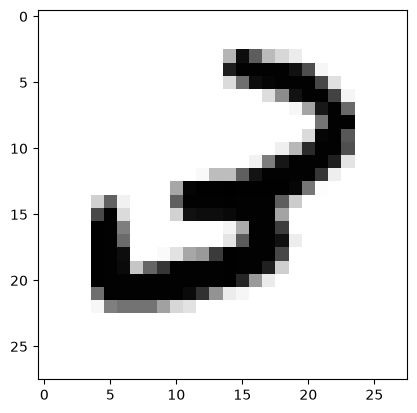

In [ ]:
# Create a version of the training data that is a 3-dimensional numpy array 
# where the first axis (axis 0) is the number of samples
mnist_train_3d = mnist_train.to_numpy().reshape(-1, 28, 28)

# Display the 6th sample in the training set
plt.imshow(mnist_train_3d[6-1], cmap=plt.cm.Greys)

### Part C

In [14]:
# Fit a PCA model using n_components = 10 using the flattened training pixels.
pca = PCA(n_components=10)
pca_reducer = pca.fit(mnist_train)

# Use the inverse_transform() method and reshape the result to match the dimensions 
# of the 3-dimensional numpy array created in Part B.
reduced = pca_reducer.transform(mnist_train)
reshaped = pca_reducer.inverse_transform(reduced)
new_images = reshaped.reshape(-1, 28, 28)

### Part D

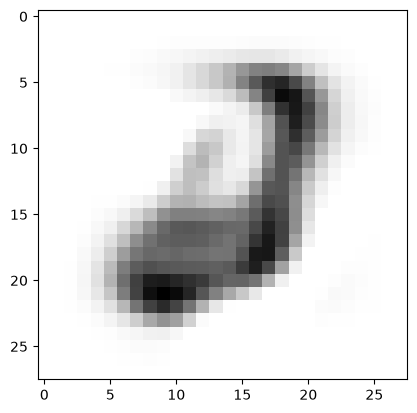

In [18]:
# Replace any negative values in the results from Part C
reshaped_no_0s = np.clip(reshaped, 0, None)

# Repeat the steps of Part B to visualize the 6th sample after dimension reduction via PCA
reshaped_no_0s_3D = reshaped_no_0s.reshape(-1, 28, 28)
plt.imshow(reshaped_no_0s_3D[6-1], cmap=plt.cm.Greys)

**Comment:** The image from part B is clearly a 3. The image after the PCA resembles the that same image of number 3 but much blurrier. I suspect this is because PCA reduced it down to using only 10 components hence there are less details in the image.

### Part E

In [38]:
n, pix1, pix2 = mnist_unflattened.shape
new_num_vals = n * 10
print(f"The original data set used {n} x {28*28} = 4,704,000 numeric values to store the pixel intensities of the entire set of images.\nIf PCA with n_components = 10 is used, we would need to store {n} x 10 = {new_num_vals} numeric values. \nTo reconstruct, we will also need to store 10 x 784 = {10*784} component weights and 784 value means.\nThus, the total is {60000 + 7840 + 784} numeric values.")

The original data set used 6000 x 784 = 4,704,000 numeric values to store the pixel intensities of the entire set of images.
If PCA with n_components = 10 is used, we would need to store 6000 x 10 = 60000 numeric values. 
To reconstruct, we will also need to store 10 x 784 = 7840 component weights and 784 value means.
Thus, the total is 68624 numeric values.


## Question 2

In [42]:
toy = pd.read_csv("https://remiller1450.github.io/data/toy_linear_data.csv")
toy.head()

,x,target
0,91.481,198.966
1,93.708,202.639
2,28.614,62.212
3,83.045,185.332
4,64.175,135.015


### Part A

Since the relationship between $x_1$ and $Y$ is linear, the best model would be a regression line. However, if I must choose between KNN or decision tree, I would pick KNN because it can approximate a line better than decision tree. KNN calculates distance so it can average neiboring values but decision tree makes orthogonal splits. It would require many splits, resembling stairs, to approximate a diagonal line.

### Part B

In [47]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# Randomly assign each observation to one of four folds using random_state=7
np.random.seed(7)
shuffled = np.random.choice(len(toy), size=len(toy), replace=False)
folds = np.array_split(shuffled, 4)

# Make an array to later store rmses
fold_rmses = []

# Loop through each fold
for i in range(4):
    validation_idx = folds[i]  # idex == i
    train_idx = np.concatenate([folds[j] for j in range(4) if j != i])  # any index != i
    
    train_X = toy.iloc[train_idx].drop(columns="target")
    train_y = toy.iloc[train_idx]["target"]
    eval_X = toy.iloc[validation_idx].drop(columns="target")
    eval_y = toy.iloc[validation_idx]["target"]
    
    # Fit a decision tree model with a maximum depth of 4
    model = DecisionTreeRegressor(max_depth=4, random_state=7)
    model.fit(train_X, train_y)
    
    # Use the model to predict on eval set
    pred = model.predict(eval_X)
    
    # Save rmse
    fold_rmses.append(root_mean_squared_error(eval_y, pred))

# Take the average
print("Mean 4-fold CV RMSEs:", sum(fold_rmses) / 4)

Mean 4-fold CV RMSEs: 6.673616318413517


### Part C

In [48]:
from sklearn.linear_model import LinearRegression

# Randomly assign each observation to one of four folds using random_state=7
np.random.seed(7)
shuffled = np.random.choice(len(toy), size=len(toy), replace=False)
folds = np.array_split(shuffled, 4)

# Make an array to later store rmses
fold_rmses = []

# Loop through each fold
for i in range(4):
    validation_idx = folds[i]  # idex == i
    train_idx = np.concatenate([folds[j] for j in range(4) if j != i])  # any index != i
    
    train_X = toy.iloc[train_idx].drop(columns="target")
    train_y = toy.iloc[train_idx]["target"]
    eval_X = toy.iloc[validation_idx].drop(columns="target")
    eval_y = toy.iloc[validation_idx]["target"]
    
    # Fit a decision tree model with a maximum depth of 4
    model = LinearRegression()
    model.fit(train_X, train_y)
    
    # Use the model to predict on eval set
    pred = model.predict(eval_X)
    
    # Save rmse
    fold_rmses.append(root_mean_squared_error(eval_y, pred))

# Take the average
print("Mean 4-fold CV RMSEs:", sum(fold_rmses) / 4)

Mean 4-fold CV RMSEs: 4.83692583643621


**Comment:** The cross-validated RMSE decreased from about 6.67 to 4.84. This is expected since we predicted that a Linear Regression would be a better model for the data.

### Part D

I would not think so. Sure, a decision tree can approximate a line with more steps but a deeper tree will also fit more random error. Thus it won't guarantee to achieve a low cross-validated RMSE like linear regression for this data.

### Part E

Because cross-validation ensures that we are not choosing a model over the other because of random noise or lucky/unlucky sampling from doing a single split with straight RMSE on training data. The choice is more reliable.

## Question 3

### Part A

In [57]:
# Read in the data
beans = pd.read_csv("https://remiller1450.github.io/data/beans.csv")

# Split the data into training and testing sets
beans_train, beans_test = train_test_split(beans,test_size=0.1,random_state=1)

### Part B

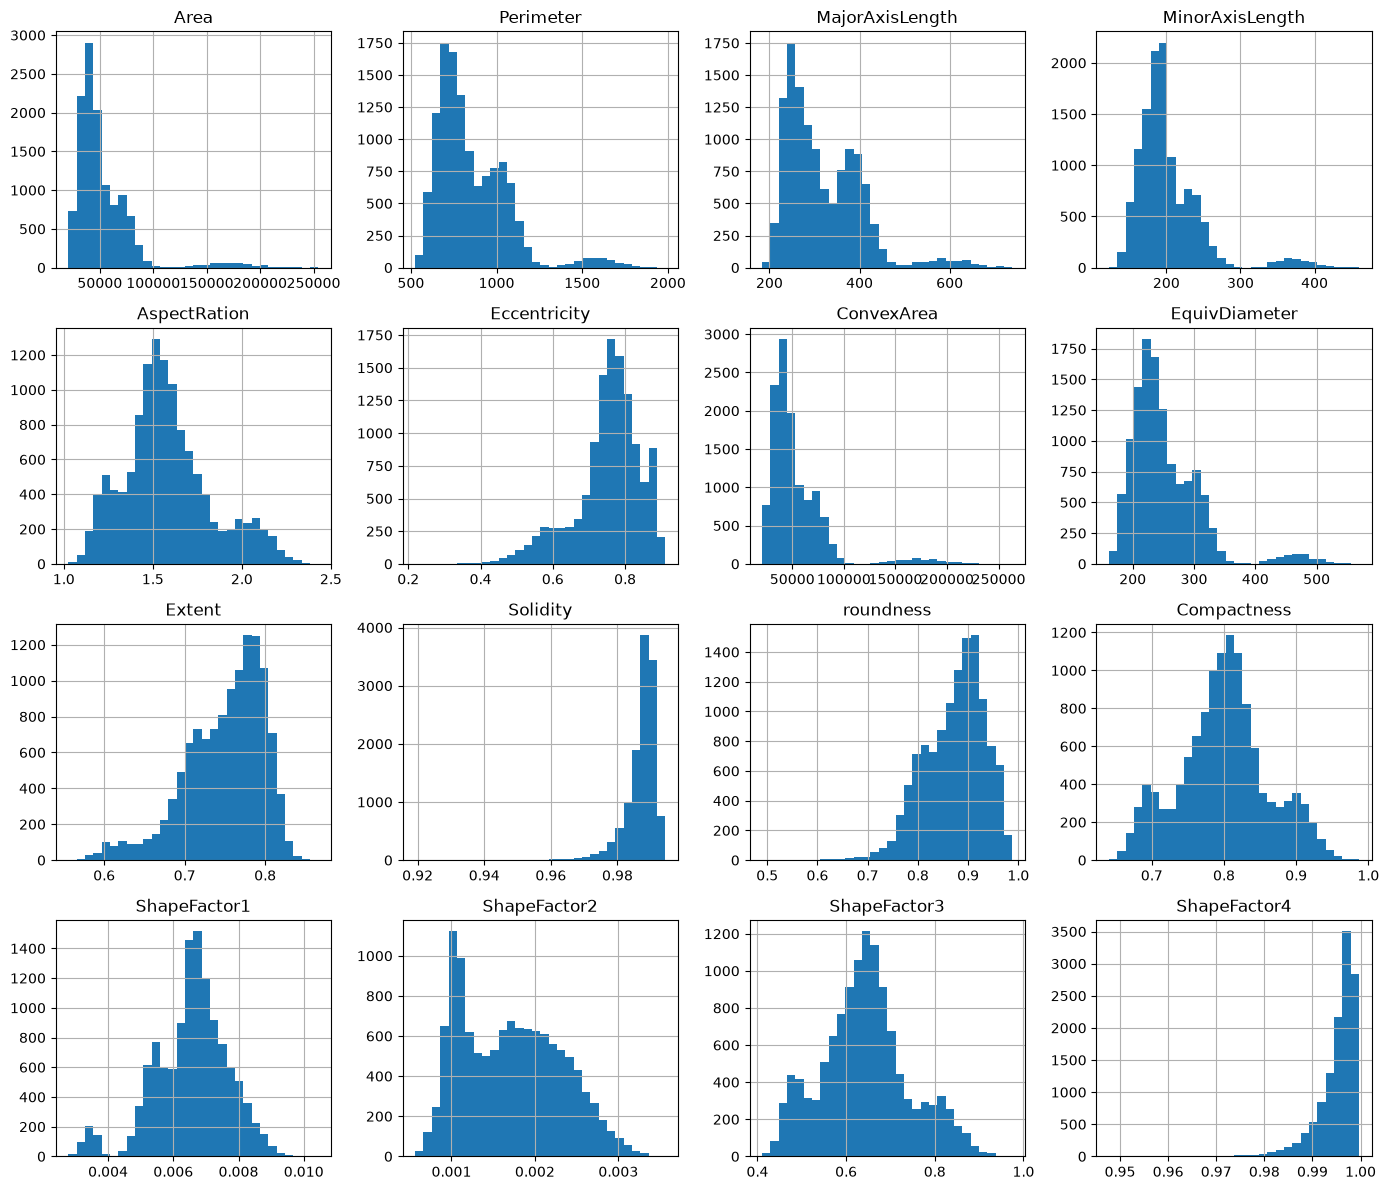

In [61]:
# Separate the outcome, `Class`, from the predictors
y_train = beans_train['Class']
y_test = beans_test['Class']
X_train = beans_train.drop(['Class'], axis=1)
X_test = beans_test.drop(['Class'], axis=1)

# Graph a histogram of every predictors
X_train.hist(figsize=(14,12), bins = 30)
plt.tight_layout()
plt.show()

**Comment:** For decision trees, re-scaling and transformation will not change the model's behavior and thus won't be needed. For $k$-nearest neighbors, yes, we should: several predictors like `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `Eccentricity`, `ConvexArea`, `EquivDiameter`, `Extent`, `Solidity`, `roundness`, `ShapeFactor4` distributions are either left or right skewed - would benefit from transformation, predictors like `ConvexArea` and `Area` have a way higher values/range - would benefit from re-scaling.

### Part C

In [65]:
correlation_matrix = np.corrcoef(X_train, rowvar=False)
print(correlation_matrix)

[[ 1.          0.96662704  0.93162572  0.95161273  0.23936087  0.26544401
   0.99993837  0.9849523   0.0505972  -0.1957884  -0.35559467 -0.26565235
  -0.84809374 -0.63945599 -0.26977336 -0.35147991]
 [ 0.96662704  1.          0.97711598  0.91326995  0.38265758  0.38892469
   0.96759382  0.99132751 -0.02328448 -0.30302799 -0.54605704 -0.40426268
  -0.86497645 -0.76769755 -0.40589792 -0.42592203]
 [ 0.93162572  0.97711598  1.          0.82583805  0.54861471  0.54072103
   0.93239158  0.96158945 -0.0799622  -0.28260074 -0.59400657 -0.56666736
  -0.77380383 -0.85972803 -0.56652732 -0.47903569]
 [ 0.95161273  0.91326995  0.82583805  1.         -0.01157825  0.01711321
   0.95135247  0.94858602  0.14255847 -0.15571491 -0.20921411 -0.01252481
  -0.94718594 -0.47150409 -0.01678417 -0.26056306]
 [ 0.23936087  0.38265758  0.54861471 -0.01157825  1.          0.92492504
   0.24090745  0.30117698 -0.36860442 -0.26422271 -0.76365671 -0.98776628
   0.02642072 -0.8369197  -0.97872834 -0.44710394]
 [ 0.

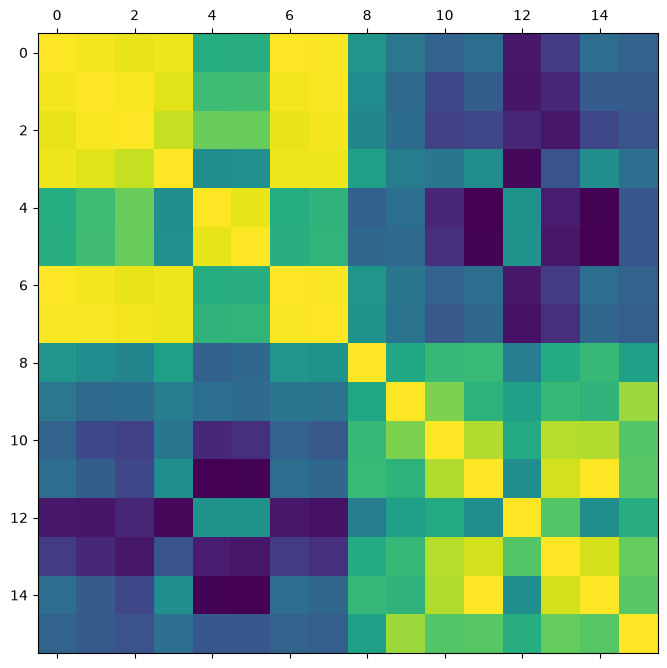

In [67]:
plt.matshow(pd.DataFrame(X_train).corr())
plt.gcf().set_size_inches(8,8)
plt.show()

**Comment:** Yes, I think PCA might be helpful because a lot of pairs (not on the diagonal line) are near +1 or -1, meaning they are highly correlated and dimension reduction could summarize with fewer components.

### Part D

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('transform', 'passthrough'),
    ('scaler', 'passthrough'),
    ('pca', 'passthrough'),
    ('model', KNeighborsClassifier())
])

params = {
    "transform": ['passthrough', PowerTransformer(standardize=False)],
    "scaler": [StandardScaler(), RobustScaler()],
    'pca': ['passthrough', PCA(n_components=0.75), PCA(n_components=0.85)],
    "model__n_neighbors": [2, 4, 6, 8],
    "model__metric": ["euclidean", "manhattan"],
    "model__weights": ["uniform", "distance"]
}

knn_grid_results = GridSearchCV(
    pipe,
    params,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
).fit(X_train, y_train)

In [81]:
knn_grid_results.best_params_

{'model__metric': 'euclidean',
 'model__n_neighbors': 8,
 'model__weights': 'distance',
 'pca': 'passthrough',
 'scaler': StandardScaler(),
 'transform': PowerTransformer(standardize=False)}

In [82]:
float(knn_grid_results.best_score_)

0.9248094932542228

### Part E

In [83]:
from sklearn.tree import DecisionTreeClassifier

pipe = Pipeline([
    ('transform', 'passthrough'),
    ('scaler', 'passthrough'),
    ('pca', 'passthrough'),
    ('model', DecisionTreeClassifier())
])

params = {
    # don't think transform or scaler is needed but the question suggests this
    "transform": ['passthrough', PowerTransformer(standardize=False)],
    "scaler": ['passthrough', StandardScaler(), RobustScaler()],
    
    'pca': ['passthrough', PCA(n_components=0.75), PCA(n_components=0.85)],
    "model__max_depth": [2, 4, 6, 10],
    "model__min_samples_split": [2, 5, 10]
}

dt_grid_results = GridSearchCV(
    pipe,
    params,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
).fit(X_train, y_train)

In [84]:
dt_grid_results.best_params_

{'model__max_depth': 10,
 'model__min_samples_split': 2,
 'pca': 'passthrough',
 'scaler': StandardScaler(),
 'transform': PowerTransformer(standardize=False)}

In [85]:
float(dt_grid_results.best_score_)

0.9032572395230039

### Part F

In [86]:
pipe = Pipeline([
    ('model', 'passthrough')
])

params = [
    {'model': [knn_grid_results.best_estimator_]},
    {'model': [dt_grid_results.best_estimator_]}
]

final_grid_results = GridSearchCV(
    pipe,
    params,
    cv=5,
    scoring="accuracy"
).fit(X_train, y_train)

final_grid_results.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](7,)","['BARBUNYA','BOMBAY','CALI',...,'HOROZ','SEKER','SIRA']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Area','Perimeter','MajorAxisLength',...,'ShapeFactor2','ShapeFactor3', 'ShapeFactor4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transform', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer in

### Part G

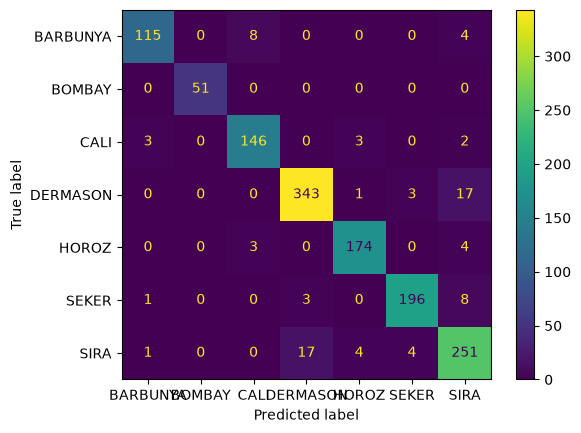

In [88]:
test_y_pred = final_grid_results.best_estimator_.predict(X_test)

## Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, test_y_pred, labels=final_grid_results.best_estimator_.classes_)
plt.show()

**Comment**: the most common types of misclassification made by the model are DERMASON predicted as SIRA and SIRA predicted as DERMASON (both at 17 count).

### Part H

In [ ]:
from sklearn.metrics import f1_score

# Report macro-averaged and micro-averaged F1-scores of the best classifier from Part F on the test data. 
test_y_pred = final_grid_results.best_estimator_.predict(X_test)
macro_f1 = f1_score(y_test, test_y_pred, average='macro')
micro_f1 = f1_score(y_test, test_y_pred, average='micro')
print(f"macro-averaged F1-score: {macro_f1}")
print(f"micro-averaged F1-score: {micro_f1}")

macro-averaged F1-score: 0.9453979333459571
micro-averaged F1-score: 0.9368575624082232


**Comment:** Looking at the confusion matrix, there is a big difference between DERMASON and BOMBAY, so if we don't want this gap to influence the performance metric of our model, we would choose macro-averaging F1-score. However, the same argument can be made against this and thus we would choose micro-averaging F1-score. So without knowing exactly the purpose and application, we cannot say definitely one metric is better than the other. We also should definitely not choose macro-averaged F1-score just because it's higher.